# **Model Comparison**

This final notebook brings together all five models developed across the project:

* the Neural-Network-based architectures (**BiLSTM** and **ULMFiT**);
* the Transformer-based architectures (**DistilBERT**, **RoBERTa**, and **DeBERTa-v3**).

It compares them directly on the same held-out test set.

The previous notebooks evaluated each family in isolation. The goal here is a single, fair
comparison along two dimensions that together determine which model is suitable for deployment:

1. **Predictive quality**: macro F1 (the headline metric for this imbalanced task), macro
precision and recall, and the F1 on the two minority classes (*Conspiratorial* and
*Critical/Skeptical*), which are the hardest and most informative.
2. **Computational cost**: the CPU inference latency per tweet and the model's size on disk,
which together indicate whether a model is practical to deploy for a given use case.

All quality metrics are recomputed uniformly from each model's saved test-set probabilities
(`probs_*.npy`), using the same functions and the same labels for every model. Since these probabilities were produced during the earlier notebooks, each in its own framework (Keras for
the BiLSTM, fastai for ULMFiT, Hugging Face for the Transformers), recomputing the metrics from
them places all five models on a common, directly comparable footing, independent of how each
notebook originally reported its results. Latency and size are read from a precomputed file and
summarised in two final artifacts: a trade-off chart and a comparison table.

In [ ]:
import os, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.metrics import f1_score, precision_score, recall_score

## **1. Set Up**

This cell detects the environment (Google Colab or local), mounts Google Drive when on Colab,and defines the paths to the data splits, the saved probabilities, and the cached latency file.

The notebook follows the display-first principle used throughout the project: it does not recompute anything expensive at run time. The quality metrics are recomputed live from the small
saved probabilities (`probs_*.npy`), while latency and model size are read from a precomputed file, `results/latency_cpu.json`.


In [ ]:
try:
    import google.colab  # noqa
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/ARTEMIS_Sentiment_Analysis'
else:
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

SPLITS_DIR  = os.path.join(PROJECT_ROOT, 'data', 'splits')
MODELS_DIR  = os.path.join(PROJECT_ROOT, 'models')
BILSTM_RES  = os.path.join(PROJECT_ROOT, 'results', 'bilstm')
ULMFIT_RES  = os.path.join(PROJECT_ROOT, 'results', 'ulmfit')
TRANSF_RES  = os.path.join(PROJECT_ROOT, 'results', 'transformers')
RESULTS_DIR = os.path.join(PROJECT_ROOT, 'results')
LATENCY_PATH = os.path.join(RESULTS_DIR, 'latency_cpu.json')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


> **Note**: Unlike the quality metrics, which are a property of the model and the data,
and can therefore be reproduced on any machine,inference latency depends on the hardware it is measured on. The values used here were measured once on the Colab CPU environment, each model in
an isolated runtime to avoid cross-framework interference, and are served as a fixed reference.
They are not recomputed in this notebook: running the same measurement on different hardware would
produce different absolute values, comparable only among themselves. The latency figures should
therefore be read as a relative, hardware-dependent indication rather than as exact timings.

## **2. Quality Metrics and Inference Latency**

This step loads the frozen test split and the shared label encoder, then computes the quality
metrics for all five models from their saved test-set probabilities (`probs_*.npy`).

Two points make the comparison fair. First, every model is evaluated on the same held-out test
set and the same label encoder used throughout the project, so the class indices and the
ground-truth labels are identical for all of them. Second, the metrics are recomputed from the
saved probabilities rather than read from each notebook's summary files: each model's prediction
is taken as the argmax of its probability array, and macro F1, macro precision, macro recall, and
the F1 of the two minority classes are computed with the same functions for every model.

This is possible because the predictions were generated and saved during the earlier notebooks,
each in its own framework (Keras for the BiLSTM, fastai for ULMFiT, Hugging Face for the
Transformers), and stored as plain probability arrays. Reusing those arrays means this quality
comparison depends only on NumPy and scikit-learn: it loads none of the original frameworks and
none of the large model files, so it runs on any machine, including a fresh clone without the
weights. The length assertion confirms each probability array is aligned to the test set before
any metric is computed.

In [ ]:
test_df = pd.read_csv(os.path.join(SPLITS_DIR, 'test_split.csv'))
with open(os.path.join(MODELS_DIR, 'label_encoder.pkl'), 'rb') as f:
    label_encoder = pickle.load(f)
test_df['label_enc'] = label_encoder.transform(test_df['label'])
y_true = test_df['label_enc'].values
target_names = list(label_encoder.classes_)

MODELS = [
    {'name': 'BiLSTM',     'probs': os.path.join(BILSTM_RES, 'probs_bilstm.npy')},
    {'name': 'ULMFiT',     'probs': os.path.join(ULMFIT_RES, 'probs_ulmfit.npy')},
    {'name': 'DistilBERT', 'probs': os.path.join(TRANSF_RES, 'probs_distilbert.npy')},
    {'name': 'RoBERTa',    'probs': os.path.join(TRANSF_RES, 'probs_roberta.npy')},
    {'name': 'DeBERTa-v3', 'probs': os.path.join(TRANSF_RES, 'probs_deberta.npy')},
]
CONSPIR  = target_names.index('Conspiratorial')
CRITICAL = target_names.index('Critical/Skeptical')

rows = []
for m in MODELS:
    preds = np.load(m['probs']).argmax(axis=1)
    assert len(preds) == len(y_true), f"{m['name']}: length mismatch"
    pcf1 = f1_score(y_true, preds, average=None, zero_division=0)
    rows.append({
        'Model':                 m['name'],
        'Macro F1':              round(f1_score(y_true, preds, average='macro', zero_division=0), 4),
        'Macro Precision':       round(precision_score(y_true, preds, average='macro', zero_division=0), 4),
        'Macro Recall':          round(recall_score(y_true, preds, average='macro', zero_division=0), 4),
        'Conspiratorial F1':     round(pcf1[CONSPIR], 4),
        'Critical/Skeptical F1': round(pcf1[CRITICAL], 4),
    })
metrics_df = pd.DataFrame(rows)



Quality alone does not determine which model is suitable for deployment; the cost of running it
matters too. For each model we consider two cost metrics: the CPU inference latency for a single
tweet and the size of the model on disk.

Unlike the quality metrics, latency is not a property of the model and the data alone: it depends
on the hardware it is measured on, so it is not recomputed here but loaded from a precomputed
file. The measurement was carried out once, on the Colab CPU environment, with the following
procedure for each model:

- the model is loaded in its native framework (Keras for the BiLSTM, fastai for ULMFiT, Hugging
Face for the Transformers);
- a single tweet is passed through the full inference path — tokenization plus the forward pass,
with batch size 1 — which reflects the cost of one live prediction in an interactive application;
- a few warm-up predictions are run and discarded (the first inference is always slower due to
lazy initialization), and the reported latency is the average over a fixed set of test tweets;
- each model is measured in a separate, freshly restarted runtime, so that only one deep
learning framework is loaded at a time. This avoids the interference that occurs when TensorFlow
and PyTorch are active together and compete for CPU resources, which would otherwise distort the
measurements.

The resulting values are stored in `results/latency_cpu.json` and simply loaded below; the table
that follows reports them directly. They are best read as approximate, hardware-dependent
indications of each model's inference cost rather than as exact timings: absolute values depend on
the specific CPU, and because each model was measured in its own runtime, the underlying hardware
may differ slightly between models. Two further factors shape the numbers: the Neural-Network-based models
process every tweet padded to a fixed length of 60 tokens regardless of its real length, and the framework wrappers (notably fastai's `predict`) add overhead beyond the model's own computation, so ULMFiT's figure in particular reflects framework cost more than raw architectural speed.

In [5]:
with open(LATENCY_PATH) as f:
    latency_data = json.load(f)


## **3. Final Comparison**

The table below collects, for all five models, the quality metrics (macro F1, macro precision,
macro recall, and the F1 of the two minority classes) alongside the two cost metrics (CPU latency
and model size). It is the single reference summarising the entire project, and supports the
choice of a model for deployment by showing quality and cost side by side. Models are ordered by macro F1.

In [6]:
table = metrics_df.copy()
table['CPU latency (ms)'] = table['Model'].map(lambda n: latency_data[n]['latency_ms'])
table['Size (MB)']        = table['Model'].map(lambda n: latency_data[n]['size_mb'])

table = table[['Model', 'Macro F1', 'Macro Precision', 'Macro Recall',
               'Conspiratorial F1', 'Critical/Skeptical F1',
               'CPU latency (ms)', 'Size (MB)']]
table = table.sort_values('Macro F1', ascending=False).reset_index(drop=True)

higher_better = ['Macro F1', 'Macro Precision', 'Macro Recall',
                 'Conspiratorial F1', 'Critical/Skeptical F1']
lower_better  = ['CPU latency (ms)', 'Size (MB)']

(table.style
    .format({'Macro F1': '{:.4f}', 'Macro Precision': '{:.4f}', 'Macro Recall': '{:.4f}',
             'Conspiratorial F1': '{:.4f}', 'Critical/Skeptical F1': '{:.4f}',
             'CPU latency (ms)': '{:.1f}', 'Size (MB)': '{:.1f}'})
    .set_caption('Final Model Comparison')
    .hide(axis='index'))

Model,Macro F1,Macro Precision,Macro Recall,Conspiratorial F1,Critical/Skeptical F1,CPU latency (ms),Size (MB)
DeBERTa-v3,0.7698,0.7695,0.7823,0.6835,0.6581,792.3,748.9
RoBERTa,0.7665,0.7510,0.7877,0.7079,0.6577,272.9,502.0
DistilBERT,0.7063,0.6959,0.7206,0.6171,0.5662,88.7,268.8
ULMFiT,0.6653,0.6478,0.7137,0.5439,0.5169,310.1,134.0
BiLSTM,0.6598,0.6592,0.6689,0.5500,0.5172,111.1,14.9


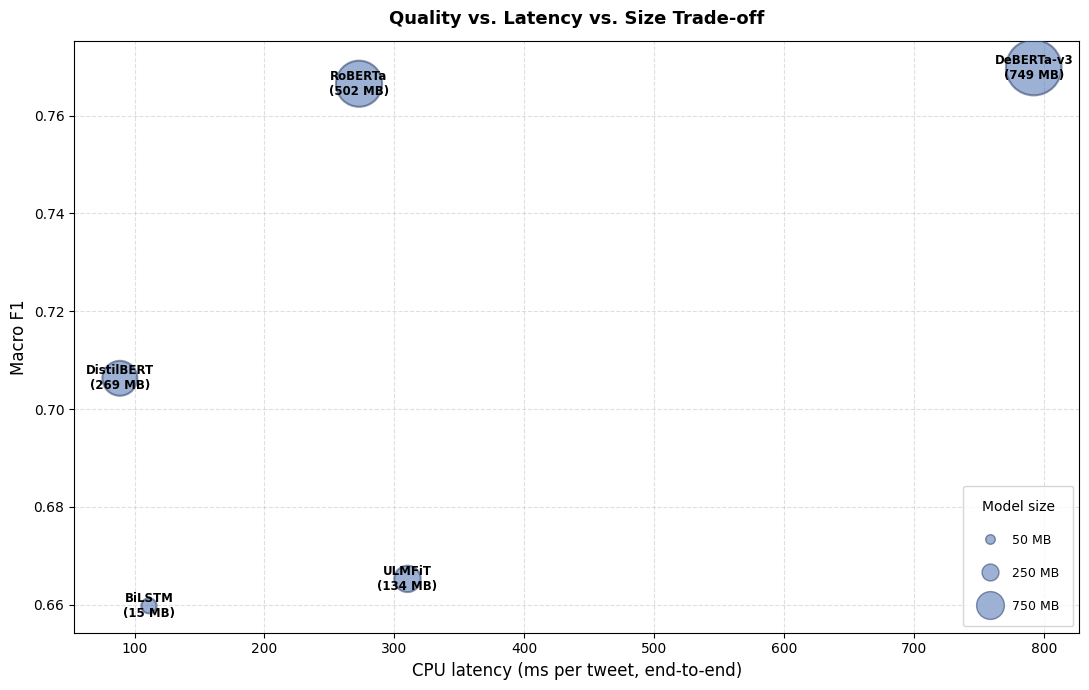

In [7]:
plot_df = metrics_df.copy()
plot_df['Latency (ms)'] = plot_df['Model'].map(lambda n: latency_data[n]['latency_ms'])
plot_df['Size (MB)']    = plot_df['Model'].map(lambda n: latency_data[n]['size_mb'])

s_min, s_max = 120, 1600
sz = plot_df['Size (MB)']
bubble = s_min + (sz - sz.min()) / (sz.max() - sz.min()) * (s_max - s_min)

fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(plot_df['Latency (ms)'], plot_df['Macro F1'],
           s=bubble, color='#4C72B0', alpha=0.55,
           edgecolor='#2C3E6B', linewidth=1.5, zorder=3)

for _, r in plot_df.iterrows():
    ax.annotate(f"{r['Model']}\n({r['Size (MB)']:.0f} MB)",
                (r['Latency (ms)'], r['Macro F1']),
                ha='center', va='center', fontsize=8.5, fontweight='bold', zorder=4)

ax.set_xlabel('CPU latency (ms per tweet)', fontsize=12)
ax.set_ylabel('Macro F1', fontsize=12)
ax.set_title('Quality vs. Latency vs. Size Trade-off',
             fontsize=13, fontweight='bold', pad=12)
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

ref_sizes = [50, 250, 750]
ref_bubbles = [s_min + (rs - sz.min()) / (sz.max() - sz.min()) * (s_max - s_min) for rs in ref_sizes]
handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor='#4C72B0',
                  alpha=0.55, markeredgecolor='#2C3E6B',
                  markersize=(b**0.5/2), label=f'{rs} MB')
           for rs, b in zip(ref_sizes, ref_bubbles)]
ax.legend(handles=handles, title='Model size', labelspacing=1.6,
          borderpad=1.1, loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

The table summarises the whole project in one view, and a clear two-tier structure emerges. The two recurrent models settle around a macro F1 of 0.66 (BiLSTM 0.660, ULMFiT 0.665), while all three Transformers move above it: DistilBERT to 0.706, and RoBERTa and DeBERTa-v3 to the top of the range at 0.766 and 0.770. The separation between the recurrent and Transformer groups is much larger than any difference within either group, confirming that the architecture family, rather
than fine differences between individual models, is what drives quality on this task.

Almost all of that improvement comes from the two minority classes. Across the move from recurrent models to Transformers, *Conspiratorial* F1 rises from roughly 0.54 to 0.68-0.71 and *Critical/Skeptical* F1 from about 0.52 to 0.66, whereas the majority classes were already handled
well by every model. Because macro F1 weights all four classes equally, these minority gains are
the main reason the Transformers pull ahead, which is consistent with the central difficulty
identified throughout the project, the overlap between the two skeptical classes.

At the top of the table, RoBERTa and DeBERTa-v3 are effectively equivalent: their macro F1 differs
by only 0.003, well within run-to-run variation. They reach that level through slightly different
balances rather than one dominating the other, RoBERTa achieves the higher *Conspiratorial* F1
(0.708 against 0.684), while DeBERTa-v3 has marginally higher macro precision and the best
*Critical/Skeptical* F1. In practical terms they should be treated as two equally strong options.

TThe evaluation proves that classification quality and computational cost do not move together. DistilBERT is the fastest architecture at 88.7 ms, faster than both the BiLSTM (111.1 ms) and ULMFiT (310.1 ms), and only mid-sized at 268.8 MB, yet it delivers a clearly higher macro F1 than either Neural-Network-based model. DeBERTa-v3 obtains the highest macro F1, but at the greatest cost on both axes: it is by far the slowest at 792.3 ms, roughly three times RoBERTa's 272.9 ms, and the largest at 748.9 MB, in exchange for an advantage over RoBERTa that is within noise.
RoBERTa, by contrast, reaches almost the same quality as DeBERTa-v3 at about a third of the latency and two-thirds of the size, which makes it the most efficient of the two top-quality models.

It is also worth noting that the Neural-Network-based models retain a genuine advantage in
footprint: the BiLSTM is by far the smallest model at 14.9 MB, far lighter than any Transformer, which would make it the appropriate choice in memory-constrained settings, even though it is outperformed on quality.

Overall, no single model is best on every dimension: DeBERTa-v3 leads on macro F1, RoBERTa on
*Conspiratorial* F1, DistilBERT on latency, and the BiLSTM on size. The right choice therefore depends on the deployment priority, DistilBERT for the best balance of speed and prediction quality, RoBERTa for the best quality-per-cost where quality prediction matters most, and DeBERTa-v3 when maximum quality is required and cost is not a constraint: however the gain with respect to RoBERTa model would be minimal to justify the usage of DeBERTa-v3.

## **4. Conclusions**

The BiLSTM and ULMFiT establish a performance baseline with Macro F1 scores of 0.6598 and 0.6653, respectively. Their error residual on short, figurative, or ambiguous text indicates an
architectural constraint that transfer learning does not resolve. Attention mechanisms overcome this limitation by addressing the vocabulary overlap within the *Conspiratorial* and
*Critical/Skeptical* minority classes. Consequently, DistilBERT surpasses the recurrent baseline with a Macro F1 of 0.7063, while RoBERTa and DeBERTa-v3 reach the highest scores in the comparison at 0.7665 and 0.7698.

Evaluating these architectures reveals that computational overhead does not correlate with
predictive power. DistilBERT operates at a lower latency of 88.7 ms than both recurrent models while delivering higher predictive quality. DeBERTa-v3 requires 792.3 ms and 748.9 MB, providing a marginal quality gain over RoBERTa, which operates at 272.9 ms and 502.0 MB. Despite its lower predictive quality, the BiLSTM maintains an advantage in memory efficiency with a footprint of 14.9 MB, positioning it as the primary option for memory-constrained environments.

Architectural selection must align with explicit deployment constraints:

1. **Maximum Speed and Efficiency**: Deploy **DistilBERT** (88.7 ms latency, 0.7063 Macro F1) for high-throughput, real-time pipelines.
2. **Balanced High Quality**: Deploy **RoBERTa** (272.9 ms latency, 0.7665 Macro F1) as the optimal quality-to-cost compromise for standard server environments.
3. **Unconstrained Quality**: Deploy **DeBERTa-v3** (0.7698 Macro F1) strictly where the marginal F1 gain outweighs a 792.3 ms latency penalty.
4. **Strict Edge Storage**: Deploy **BiLSTM** (14.9 MB) where extreme memory limits prohibit
Transformer deployment.